# Model identifiability and posterior predictive checks

The confusion matrices assess whether data generated by each clean RDM model are assigned back to that model. The posterior predictive checks assess whether each assumed model can reproduce condition-specific accuracy and reaction-time distributions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "benchmark").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Could not locate the benchmark package.")
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.diffusion.config import FIGURE_DIR, TrainingConfig
from benchmark.examples.diffusion.results.model_checks import (
    PPC_PATH,
    compute_or_load_ppc,
    compute_or_load_npe_ppc,
    confusion_matrices,
    generate_npe_ppc_density_figures,
    generate_stan_ppc_density_figure,
    plot_empirical_ppc,
    plot_empirical_pmp_error_boxplots,
    plot_matrix_grid,
    plot_ppc_misfit_heatmap,
    ppc_misfit_summary,
    random_ppc_participant,
)
from benchmark.examples.diffusion.results.multisource_pipeline import load_cached_all_observed

PLOT_DIR = FIGURE_DIR / "model_checks"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CONFIGS = {
    "S=D": TrainingConfig(summary_multiplier=1),
    "S=2D": TrainingConfig(summary_multiplier=2),
    "S=4D": TrainingConfig(summary_multiplier=4),
    "S=6D": TrainingConfig(summary_multiplier=6),
}
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11})

INFO:bayesflow:Using backend 'tensorflow'


## Confusion matrices

Rows are data-generating models and columns are selected models. Only the clean `simulated_from_m0` to `simulated_from_m3` datasets are used.

In [2]:
results_by_summary = {
    label: load_cached_all_observed(config)["results"]
    for label, config in SUMMARY_CONFIGS.items()
}
hard_confusion, mean_pmp = confusion_matrices(results_by_summary)

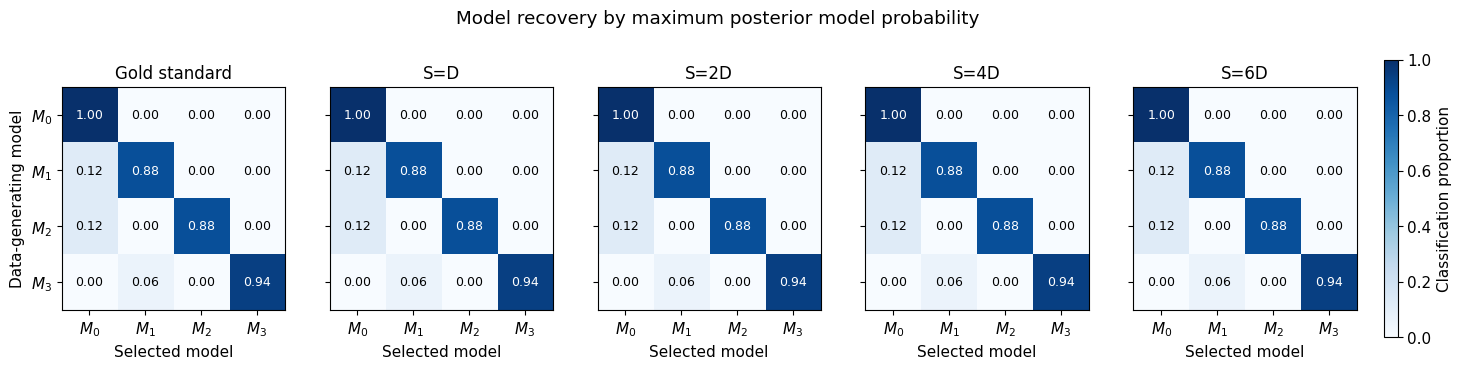

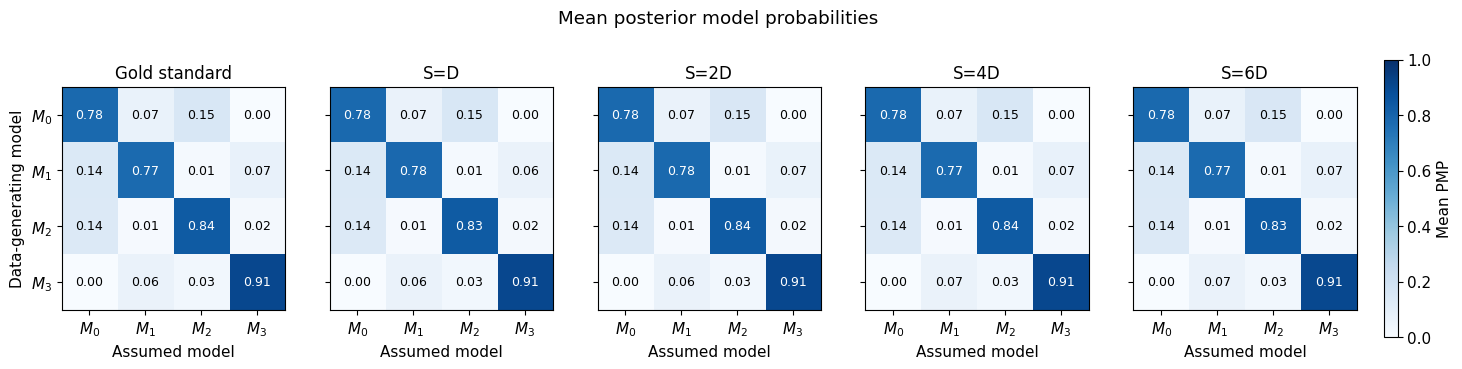

In [3]:
fig_hard, axes_hard = plot_matrix_grid(
    hard_confusion,
    title="Model recovery by maximum posterior model probability",
    colorbar_label="Classification proportion",
    filename=PLOT_DIR / "model_confusion_matrix.png",
)
plt.show()

fig_mean, axes_mean = plot_matrix_grid(
    mean_pmp,
    title="Mean posterior model probabilities",
    colorbar_label="Mean PMP",
    filename=PLOT_DIR / "mean_pmp_matrix.png",
)
plt.show()

## Empirical PMP error across summary dimensions

Each panel corresponds to one assumed model in the full four-model comparison. Each box contains the signed PMP errors of the 17 empirical participants.

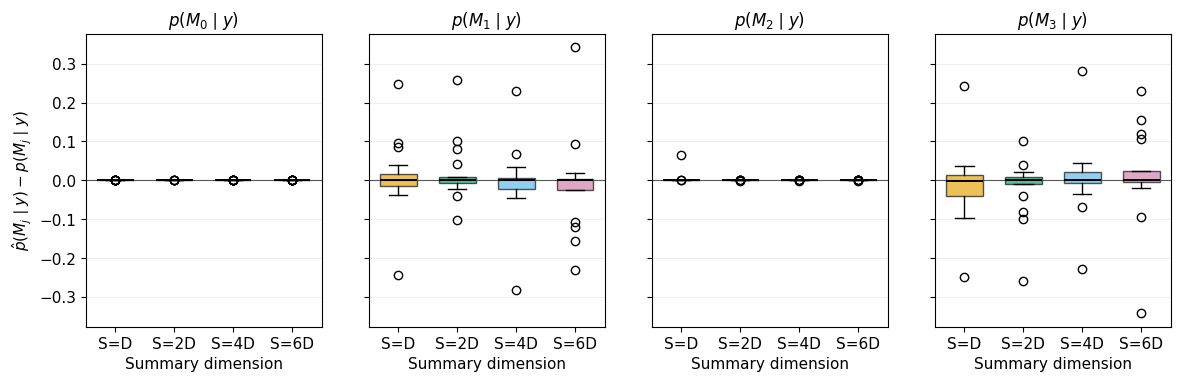

In [4]:
fig_pmp_box, axes_pmp_box = plot_empirical_pmp_error_boxplots(
    results_by_summary,
    filename=PLOT_DIR / "empirical_pmp_error_by_summary_dimension.png",
)
plt.show()

## Stan posterior predictive checks

The first run simulates replicated datasets from the existing Stan posterior draws and saves the checks to `results/posterior_predictive_checks/stan_ppc.csv`. Later runs load this cache. Set `RECOMPUTE = True` only when the observed datasets or posterior draws change; cache settings are checked automatically.

`c0` is the accuracy condition and `c1` is the speed condition. Positive RT denotes a correct response and negative RT denotes an error.

In [5]:
RECOMPUTE = True
ppc = compute_or_load_ppc(
    num_draws=256,
    interval=0.90,
    seed=2025,
    recompute=RECOMPUTE,
)
print(f"PPC cache: {PPC_PATH}")
print(f"Rows: {len(ppc):,}")
ppc.head()

PPC cache: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/posterior_predictive_checks/stan_ppc.csv
Rows: 7,592


,dataset,id,model,statistic,observed,predictive_lower,predictive_median,predictive_upper,predictive_percentile,outside_interval,num_predictive_draws,requested_num_draws,interval
0,empirical,p0,m0,accuracy_c0,0.901042,0.848958,0.890625,0.932292,0.640625,False,256,256,0.9
1,empirical,p0,m0,rt_q10_c0_correct,0.470000,0.434046,0.549097,0.720007,0.152344,False,256,256,0.9
2,empirical,p0,m0,rt_q50_c0_correct,0.578000,0.564225,0.683716,0.850344,0.066406,False,256,256,0.9
3,empirical,p0,m0,rt_q90_c0_correct,0.811200,0.803530,0.931417,1.092905,0.062500,False,256,256,0.9
4,empirical,p0,m0,rt_q10_c0_error,0.469000,0.435645,0.572853,0.744935,0.089844,False,256,256,0.9


In [6]:
ppc_summary = ppc_misfit_summary(ppc)
ppc_summary.pivot(index="dataset", columns="model", values="outside_rate").round(3)

model,m0,m1,m2,m3
dataset,,,,
empirical,0.513,0.298,0.529,0.269
m3_fast_30,0.601,0.437,0.555,0.155
m3_fast_slow_30,0.727,0.529,0.601,0.361
m3_slow_30,0.798,0.626,0.672,0.403
simulated_from_m0,0.025,0.021,0.017,0.008
simulated_from_m1,0.458,0.038,0.412,0.008
simulated_from_m2,0.504,0.496,0.038,0.013
simulated_from_m3,0.789,0.457,0.672,0.017


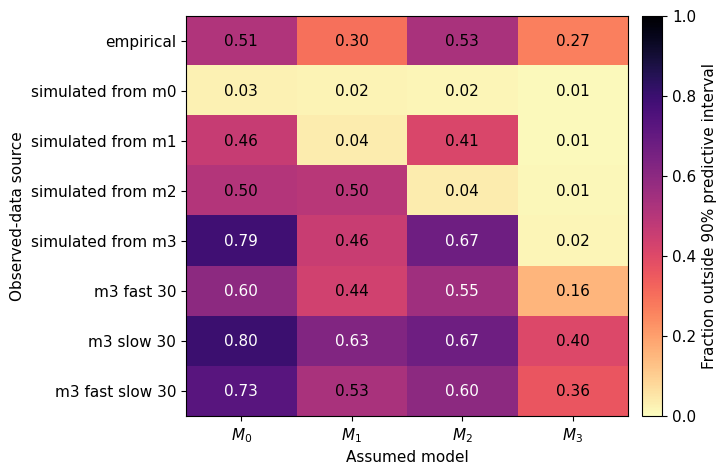

In [7]:
fig_ppc, ax_ppc = plot_ppc_misfit_heatmap(
    ppc,
    filename=PLOT_DIR / "stan_ppc_misfit_by_source.png",
)
plt.show()



## NPE posterior predictive checks

This repeats the Stan heatmap using replicated datasets generated from NPE posterior samples. Change `NPE_SUMMARY` to select another trained summary dimension.

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

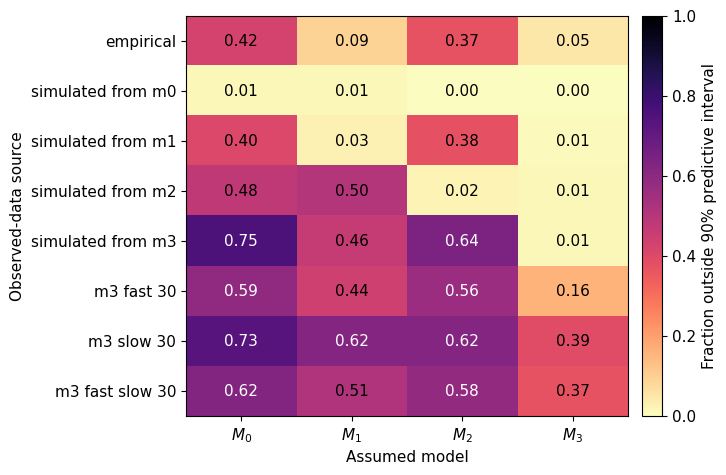

In [8]:
NPE_SUMMARY = "S=D"
npe_config = SUMMARY_CONFIGS[NPE_SUMMARY]

npe_ppc = compute_or_load_npe_ppc(
    config=npe_config,
    num_draws=256,
    interval=0.90,
    batch_size=8,
    seed=2025,
    recompute=True,
)

fig_npe_ppc, ax_npe_ppc = plot_ppc_misfit_heatmap(
    npe_ppc,
    filename=PLOT_DIR / f"npe_ppc_misfit_by_source_{npe_config.summary_label}.png",
)
plt.show()

## Posterior predictive RT densities

Generate absolute-RT density checks for NPE at S=D, 2D, 4D, and 6D, plus the single Stan reference. Correct and error responses are shown separately within the accuracy and speed conditions.

Randomly selected participant: p7 (seed=2025)


Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

...

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

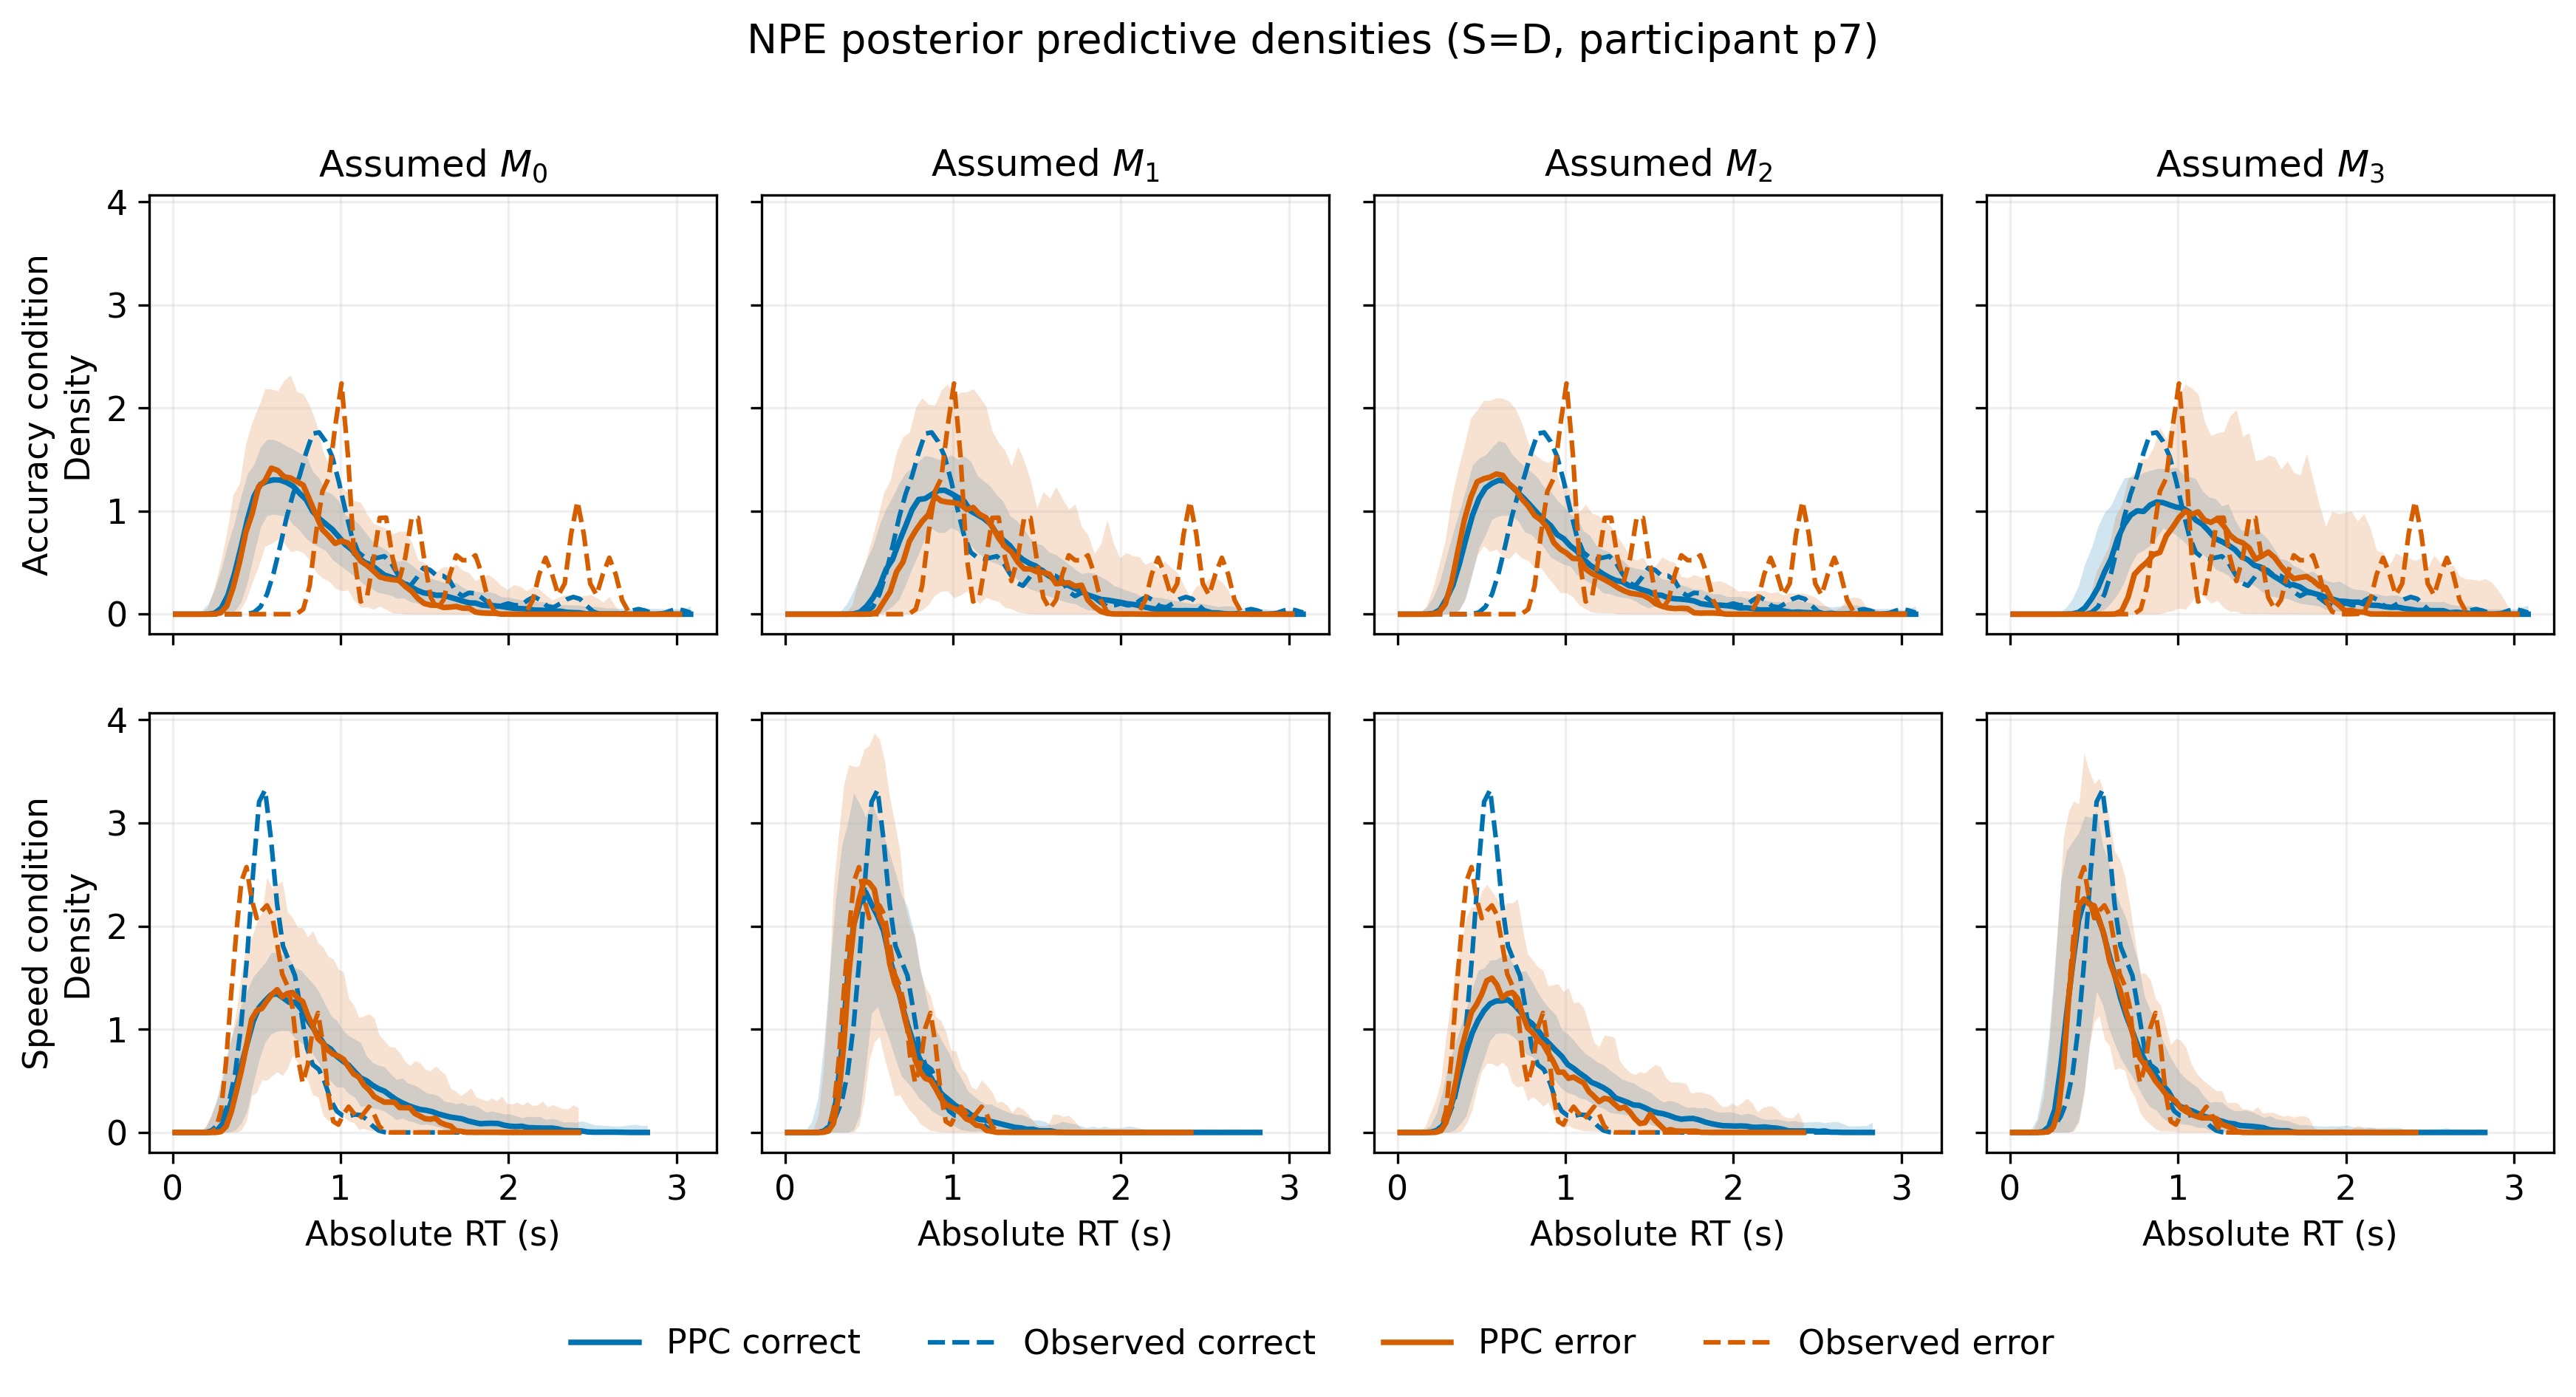

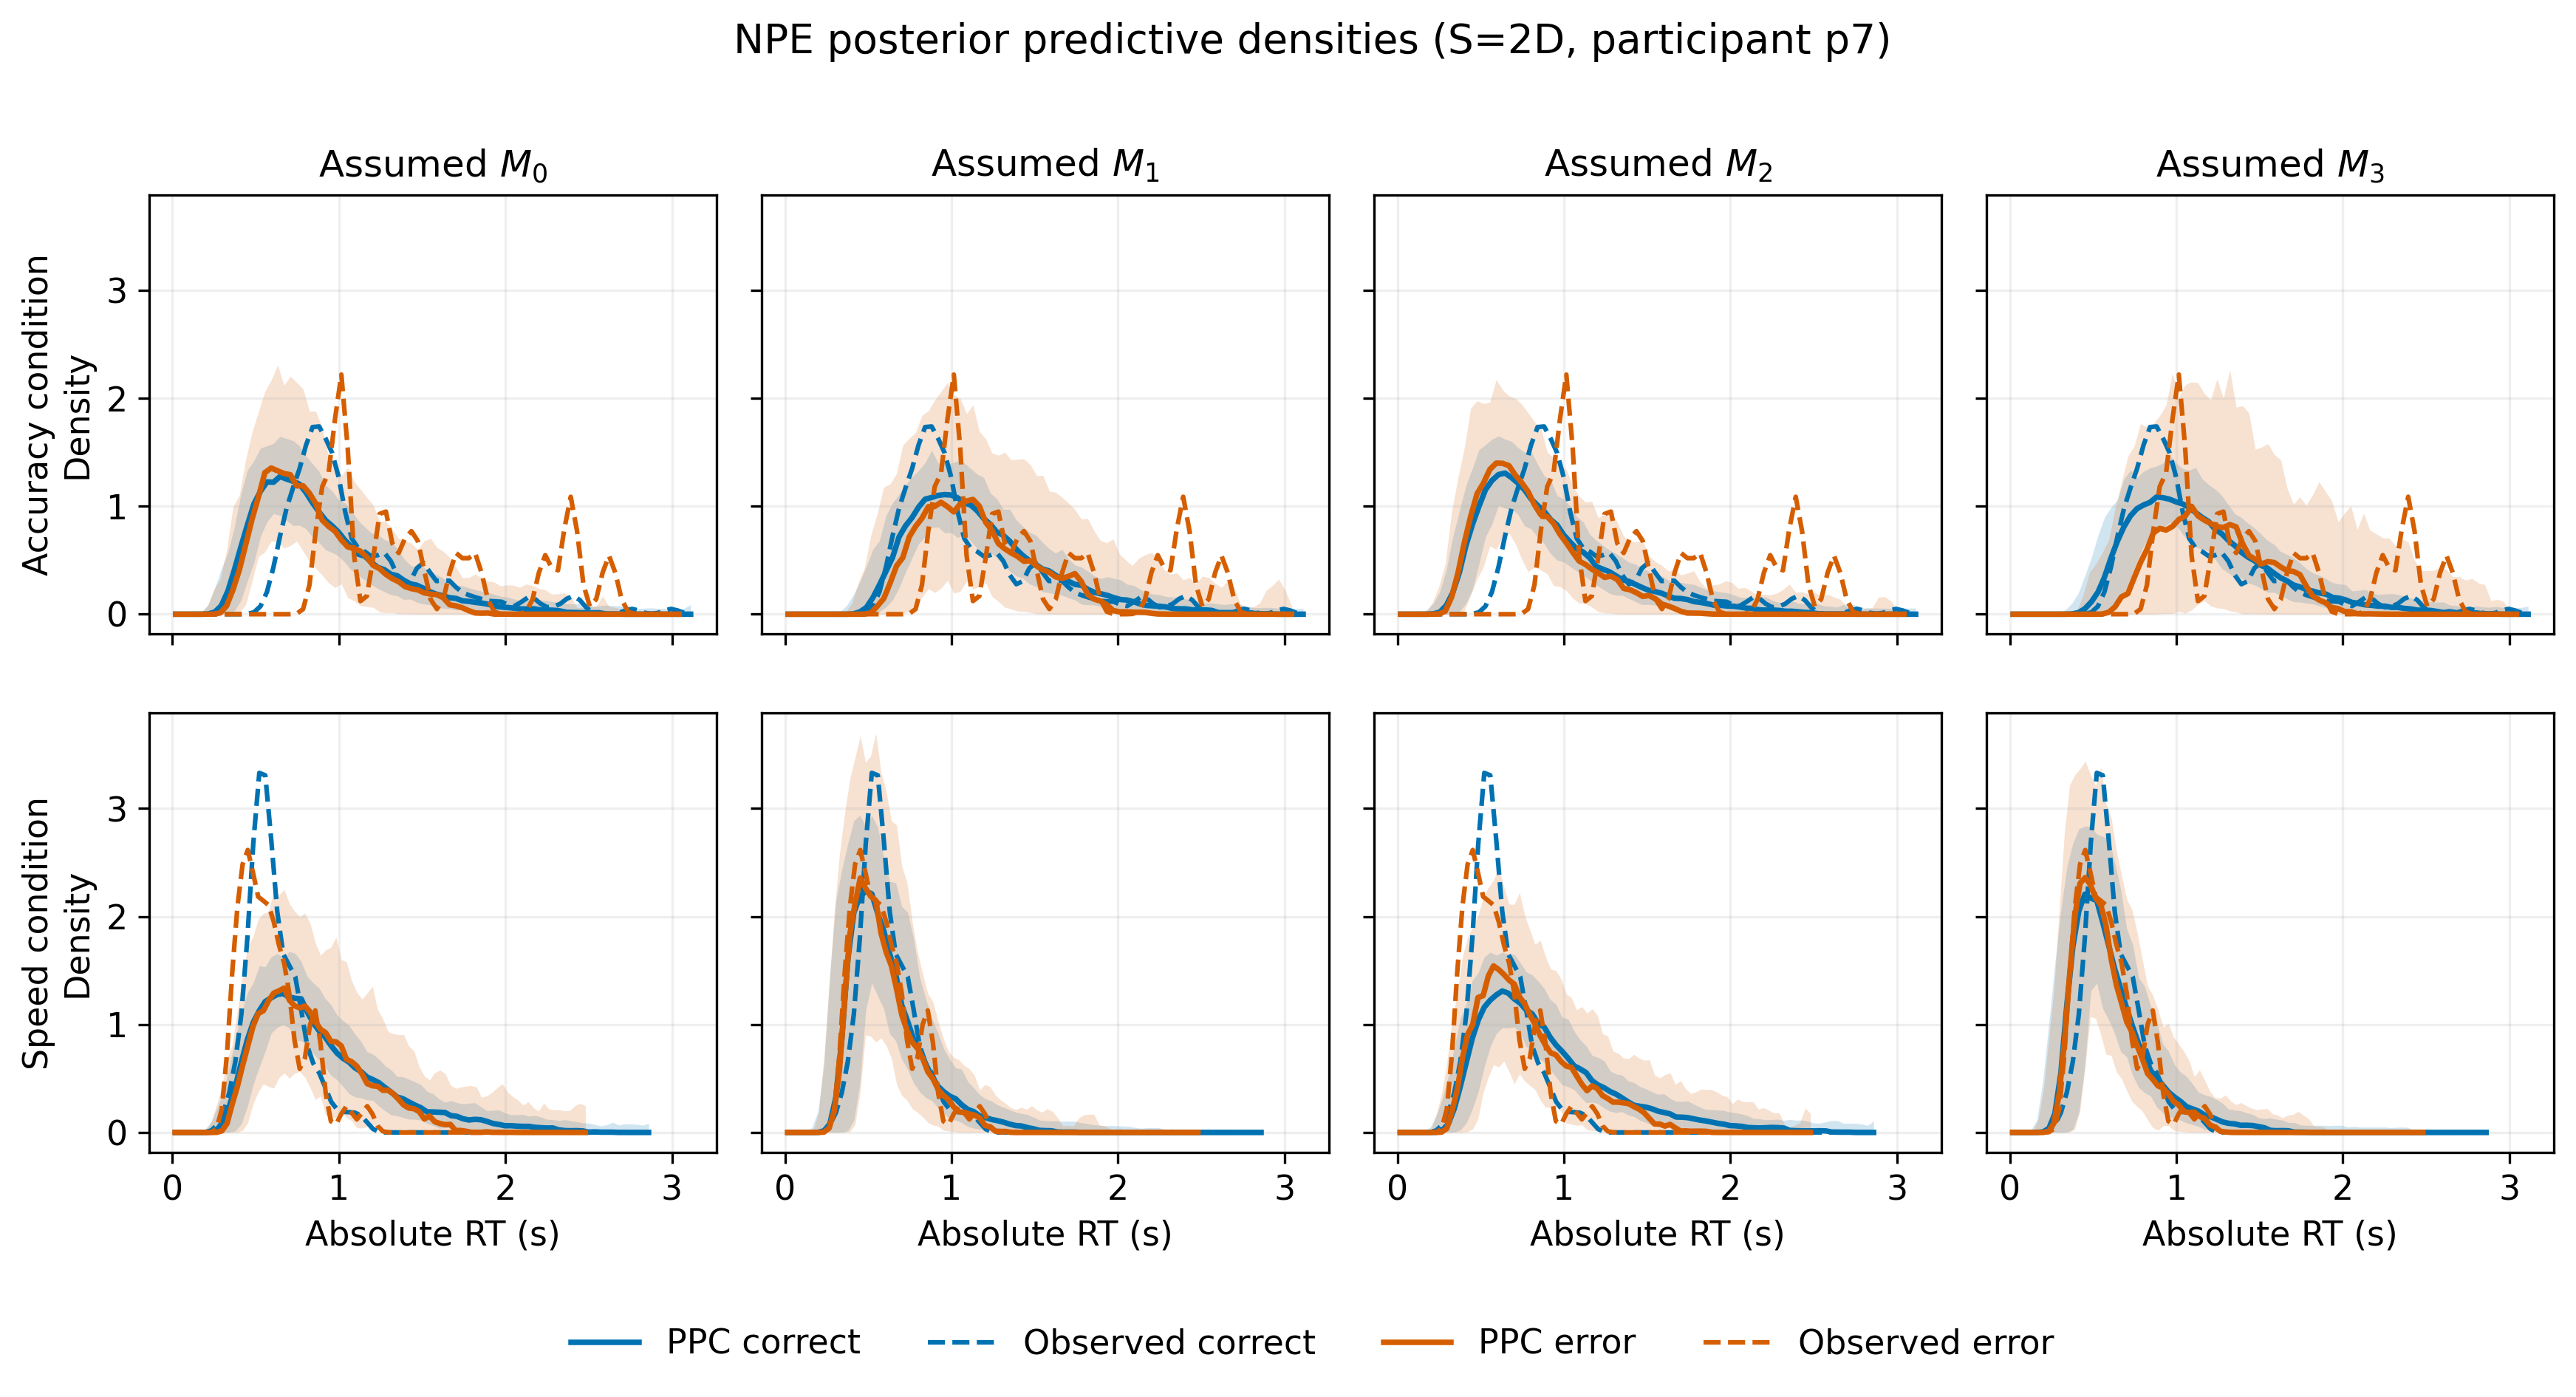

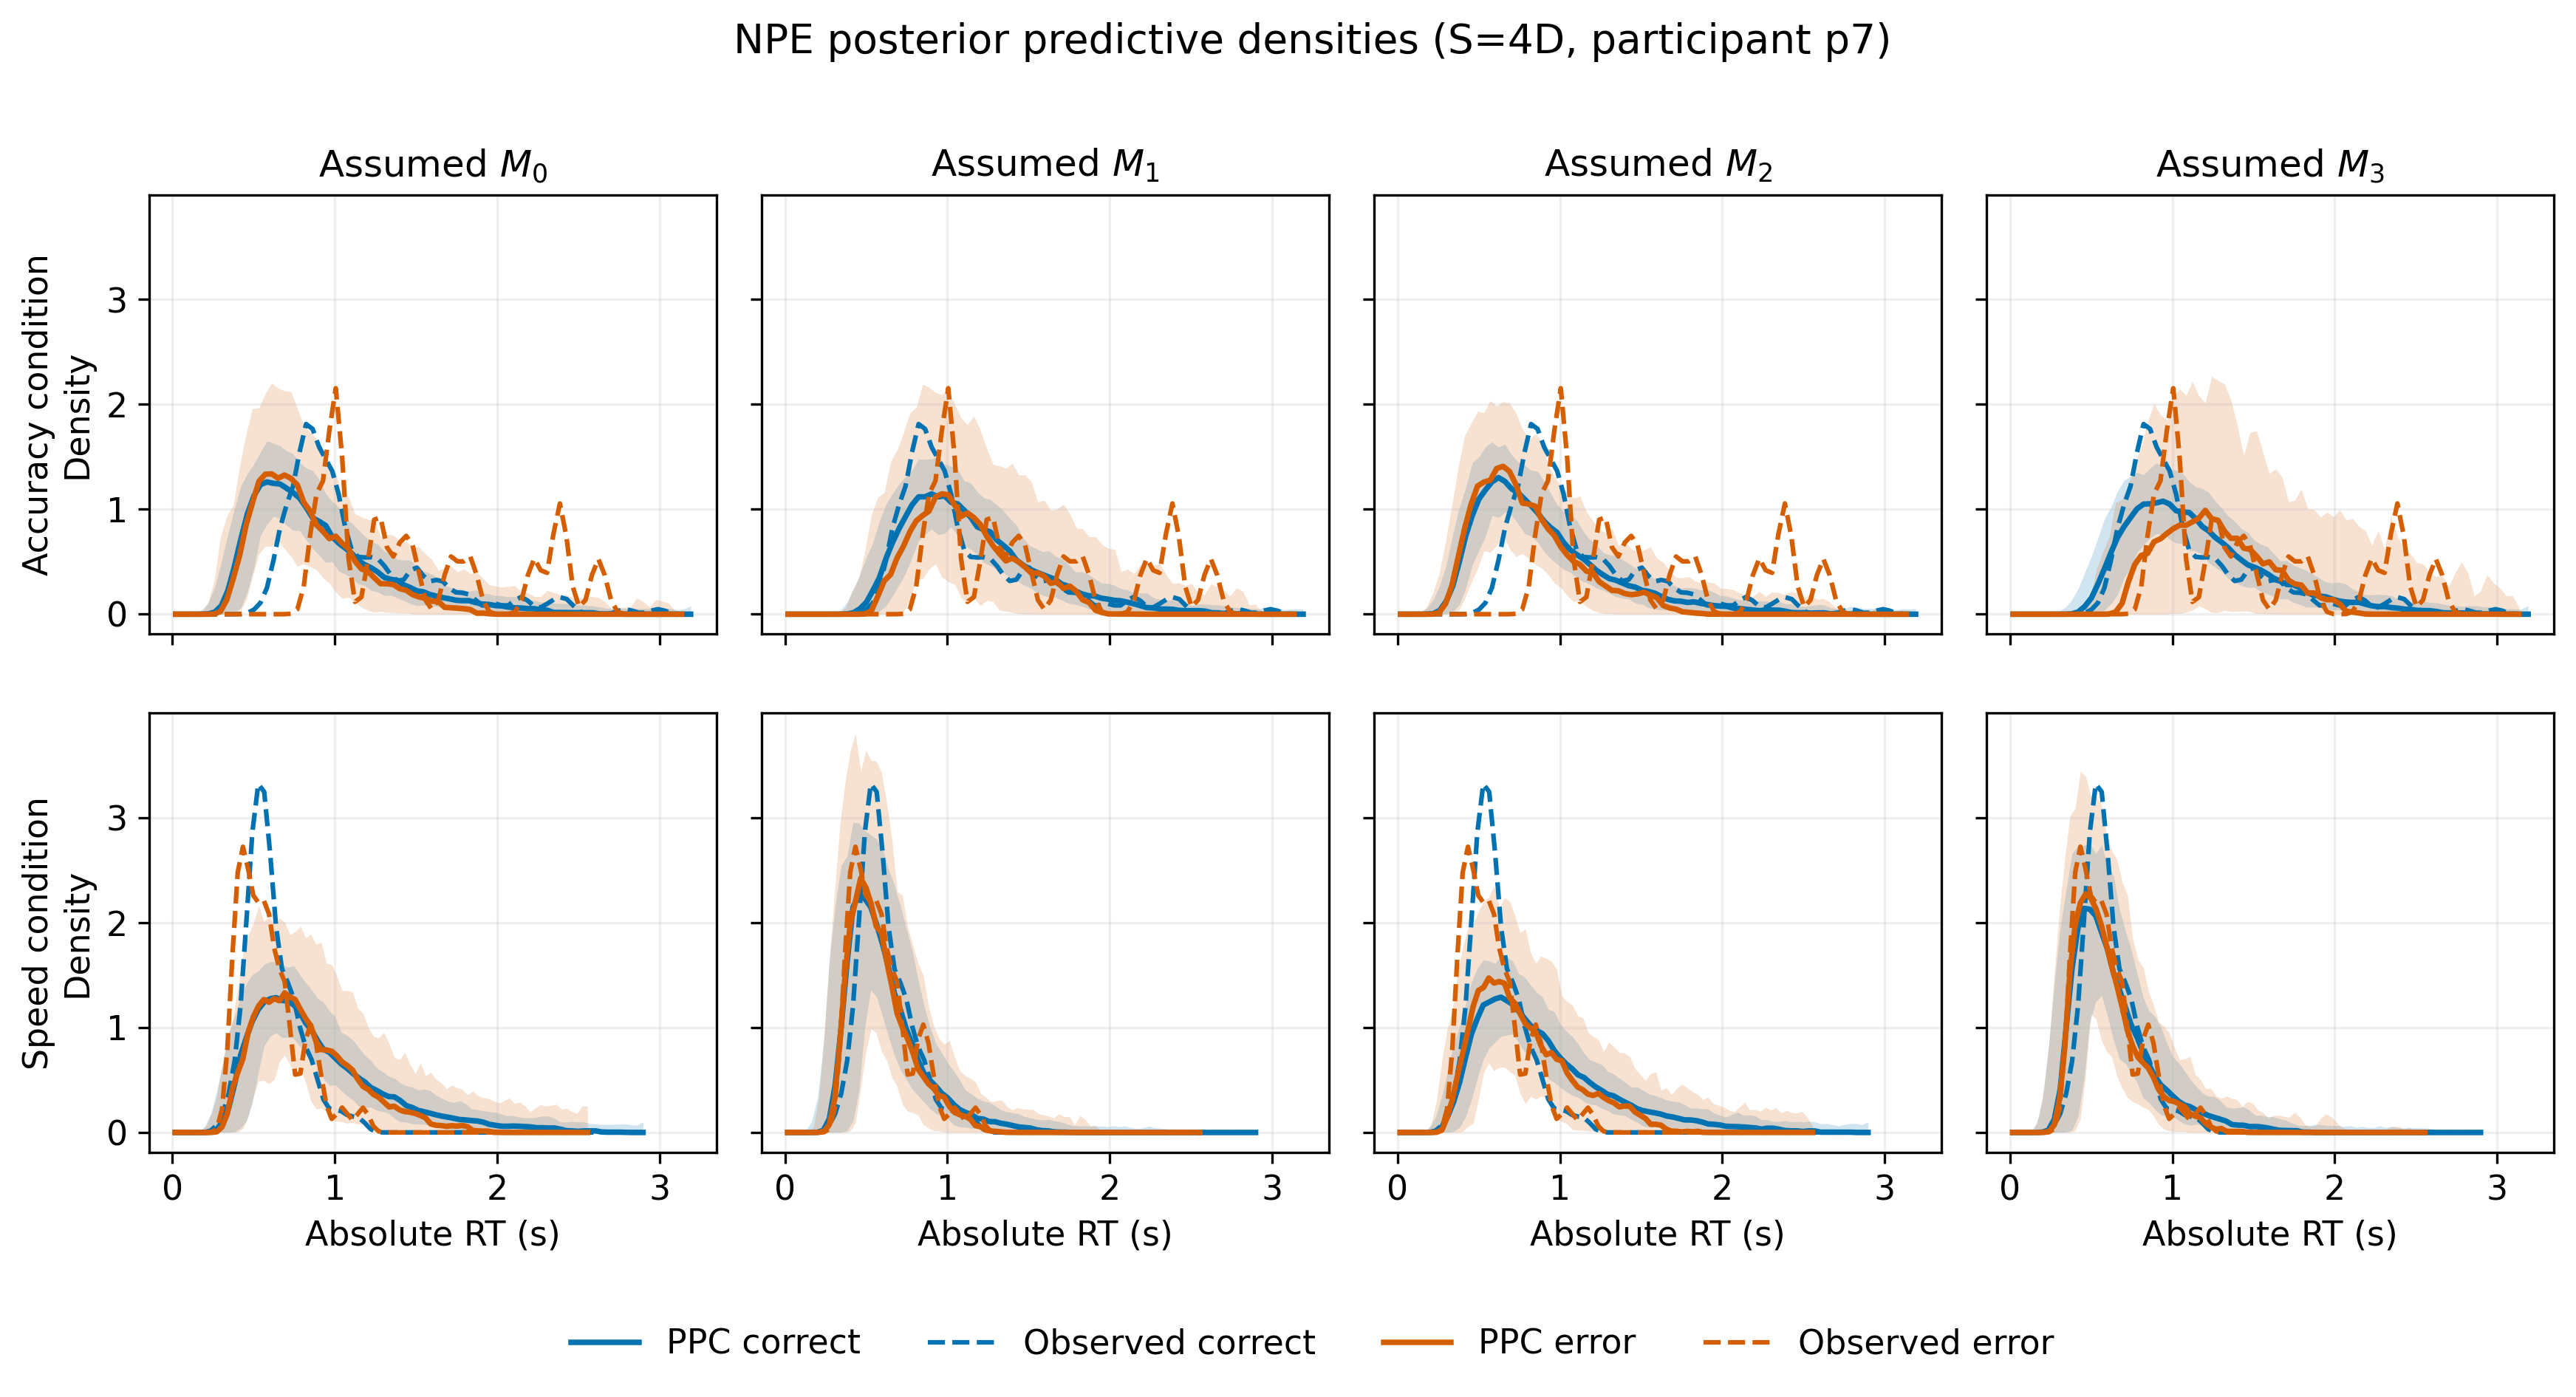

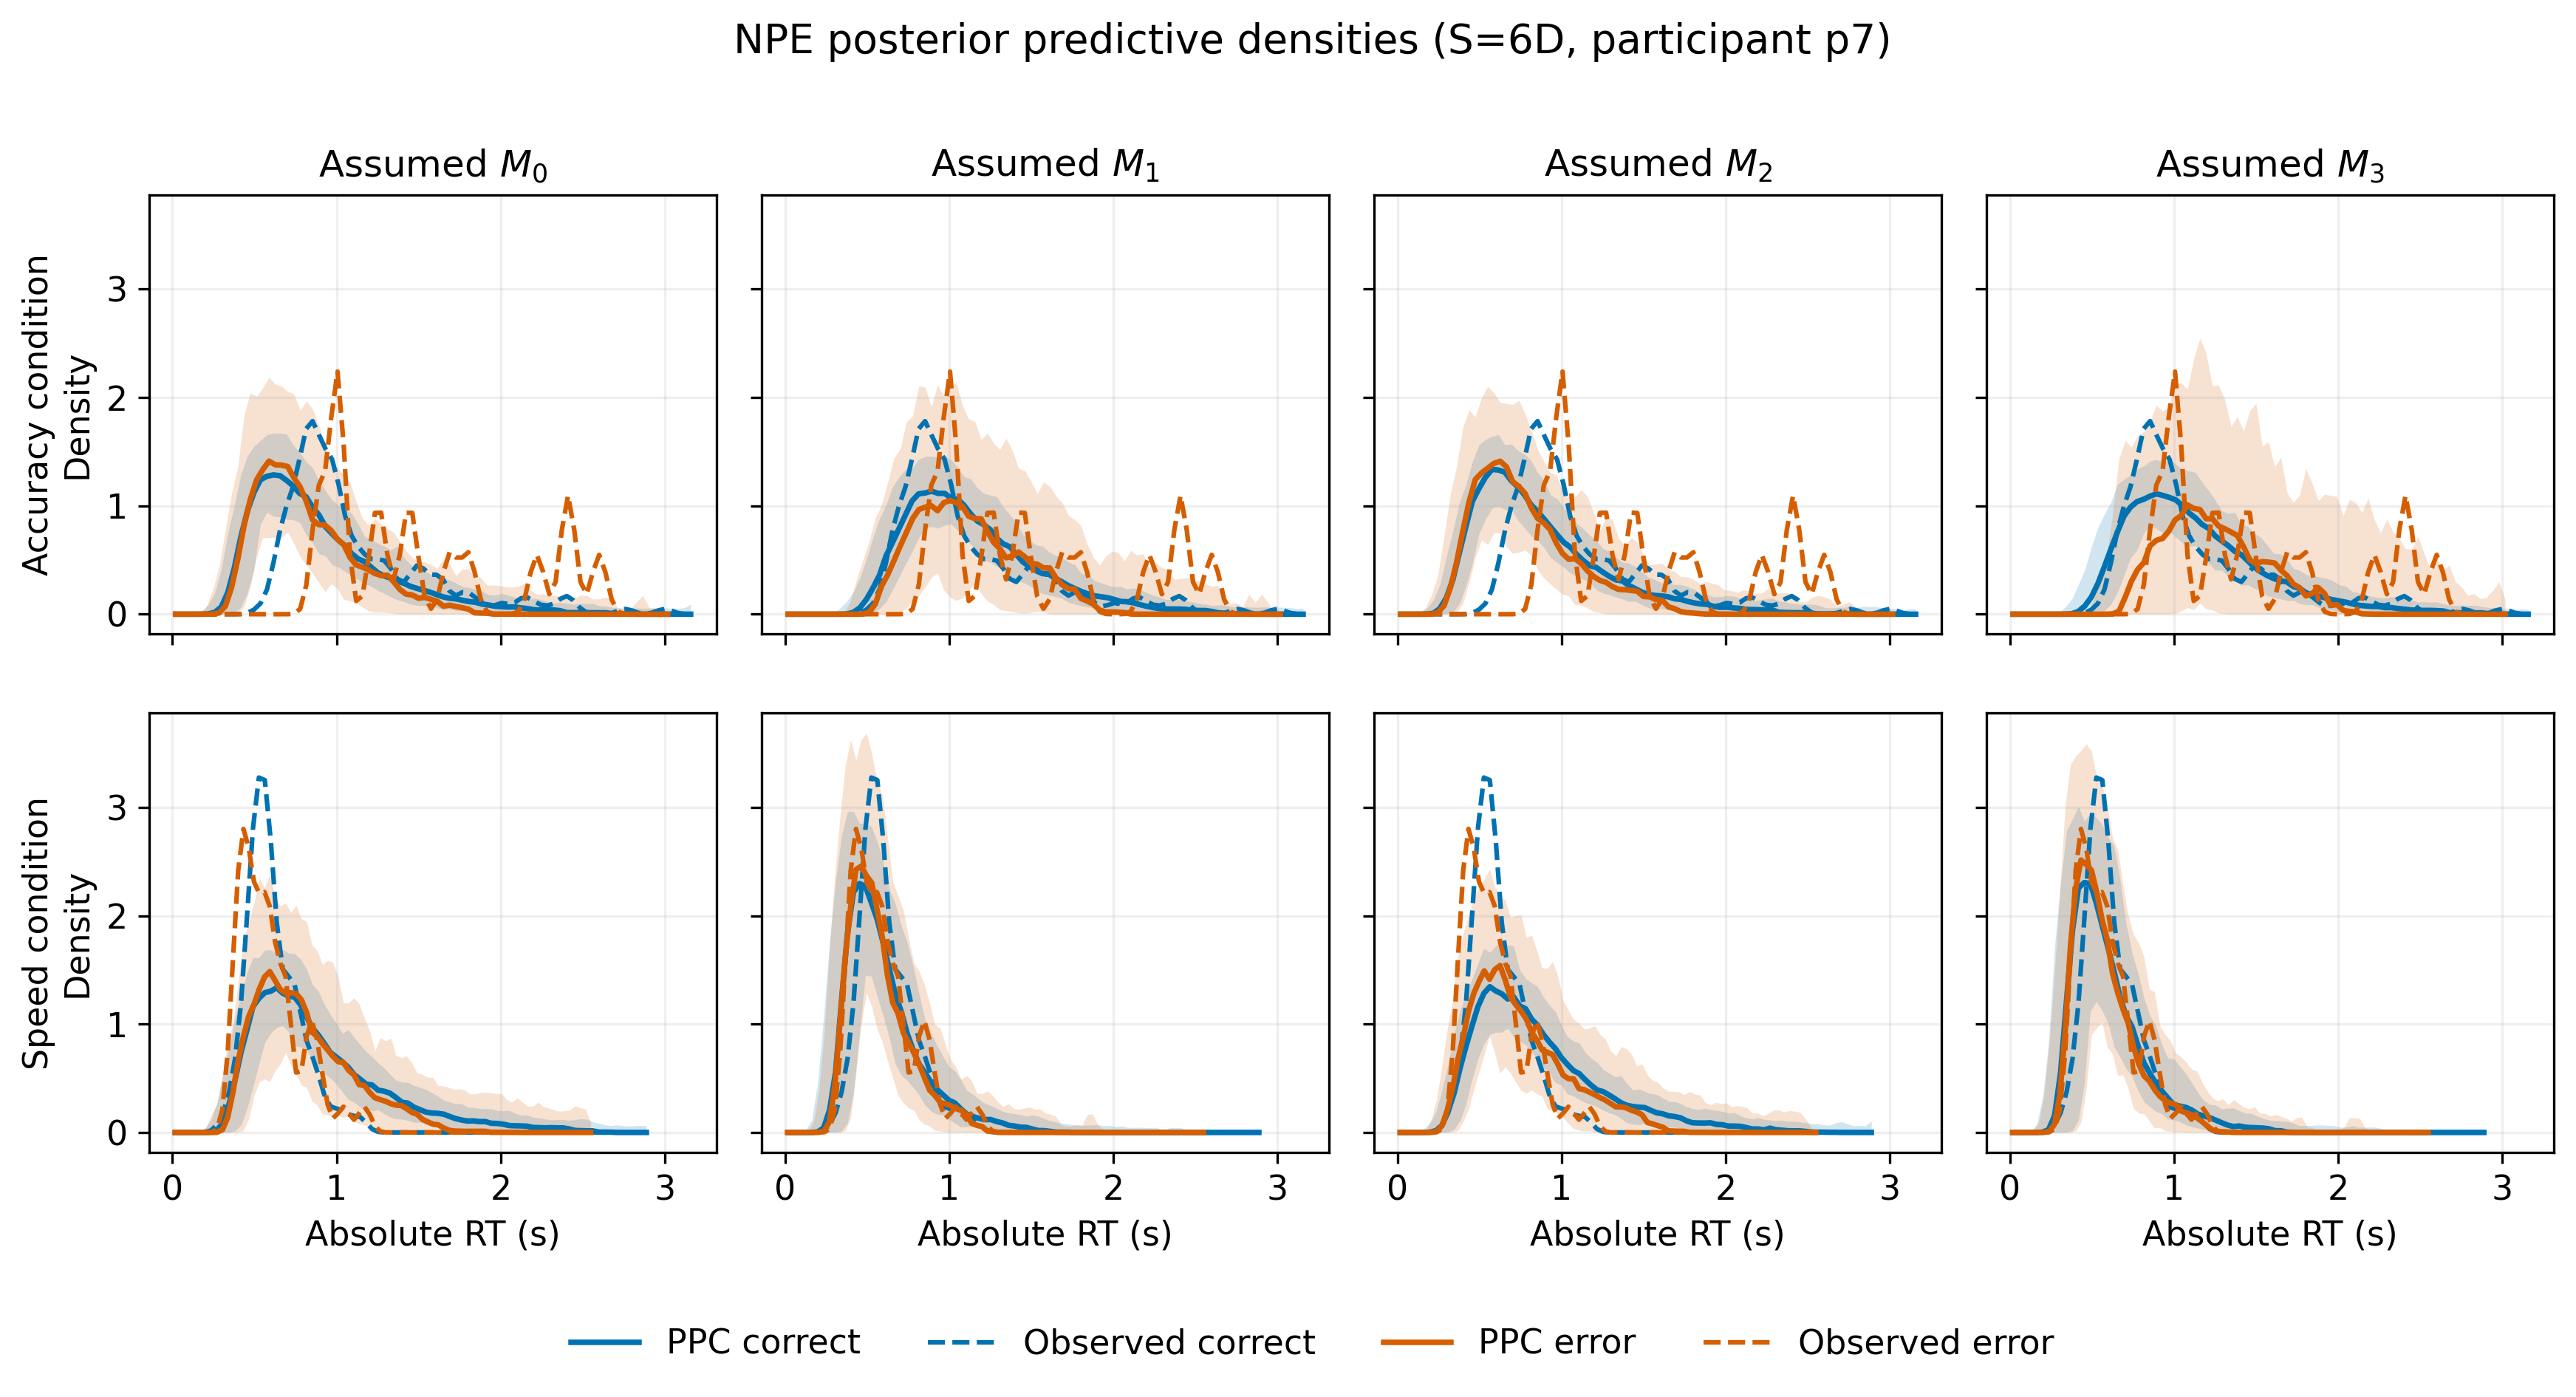

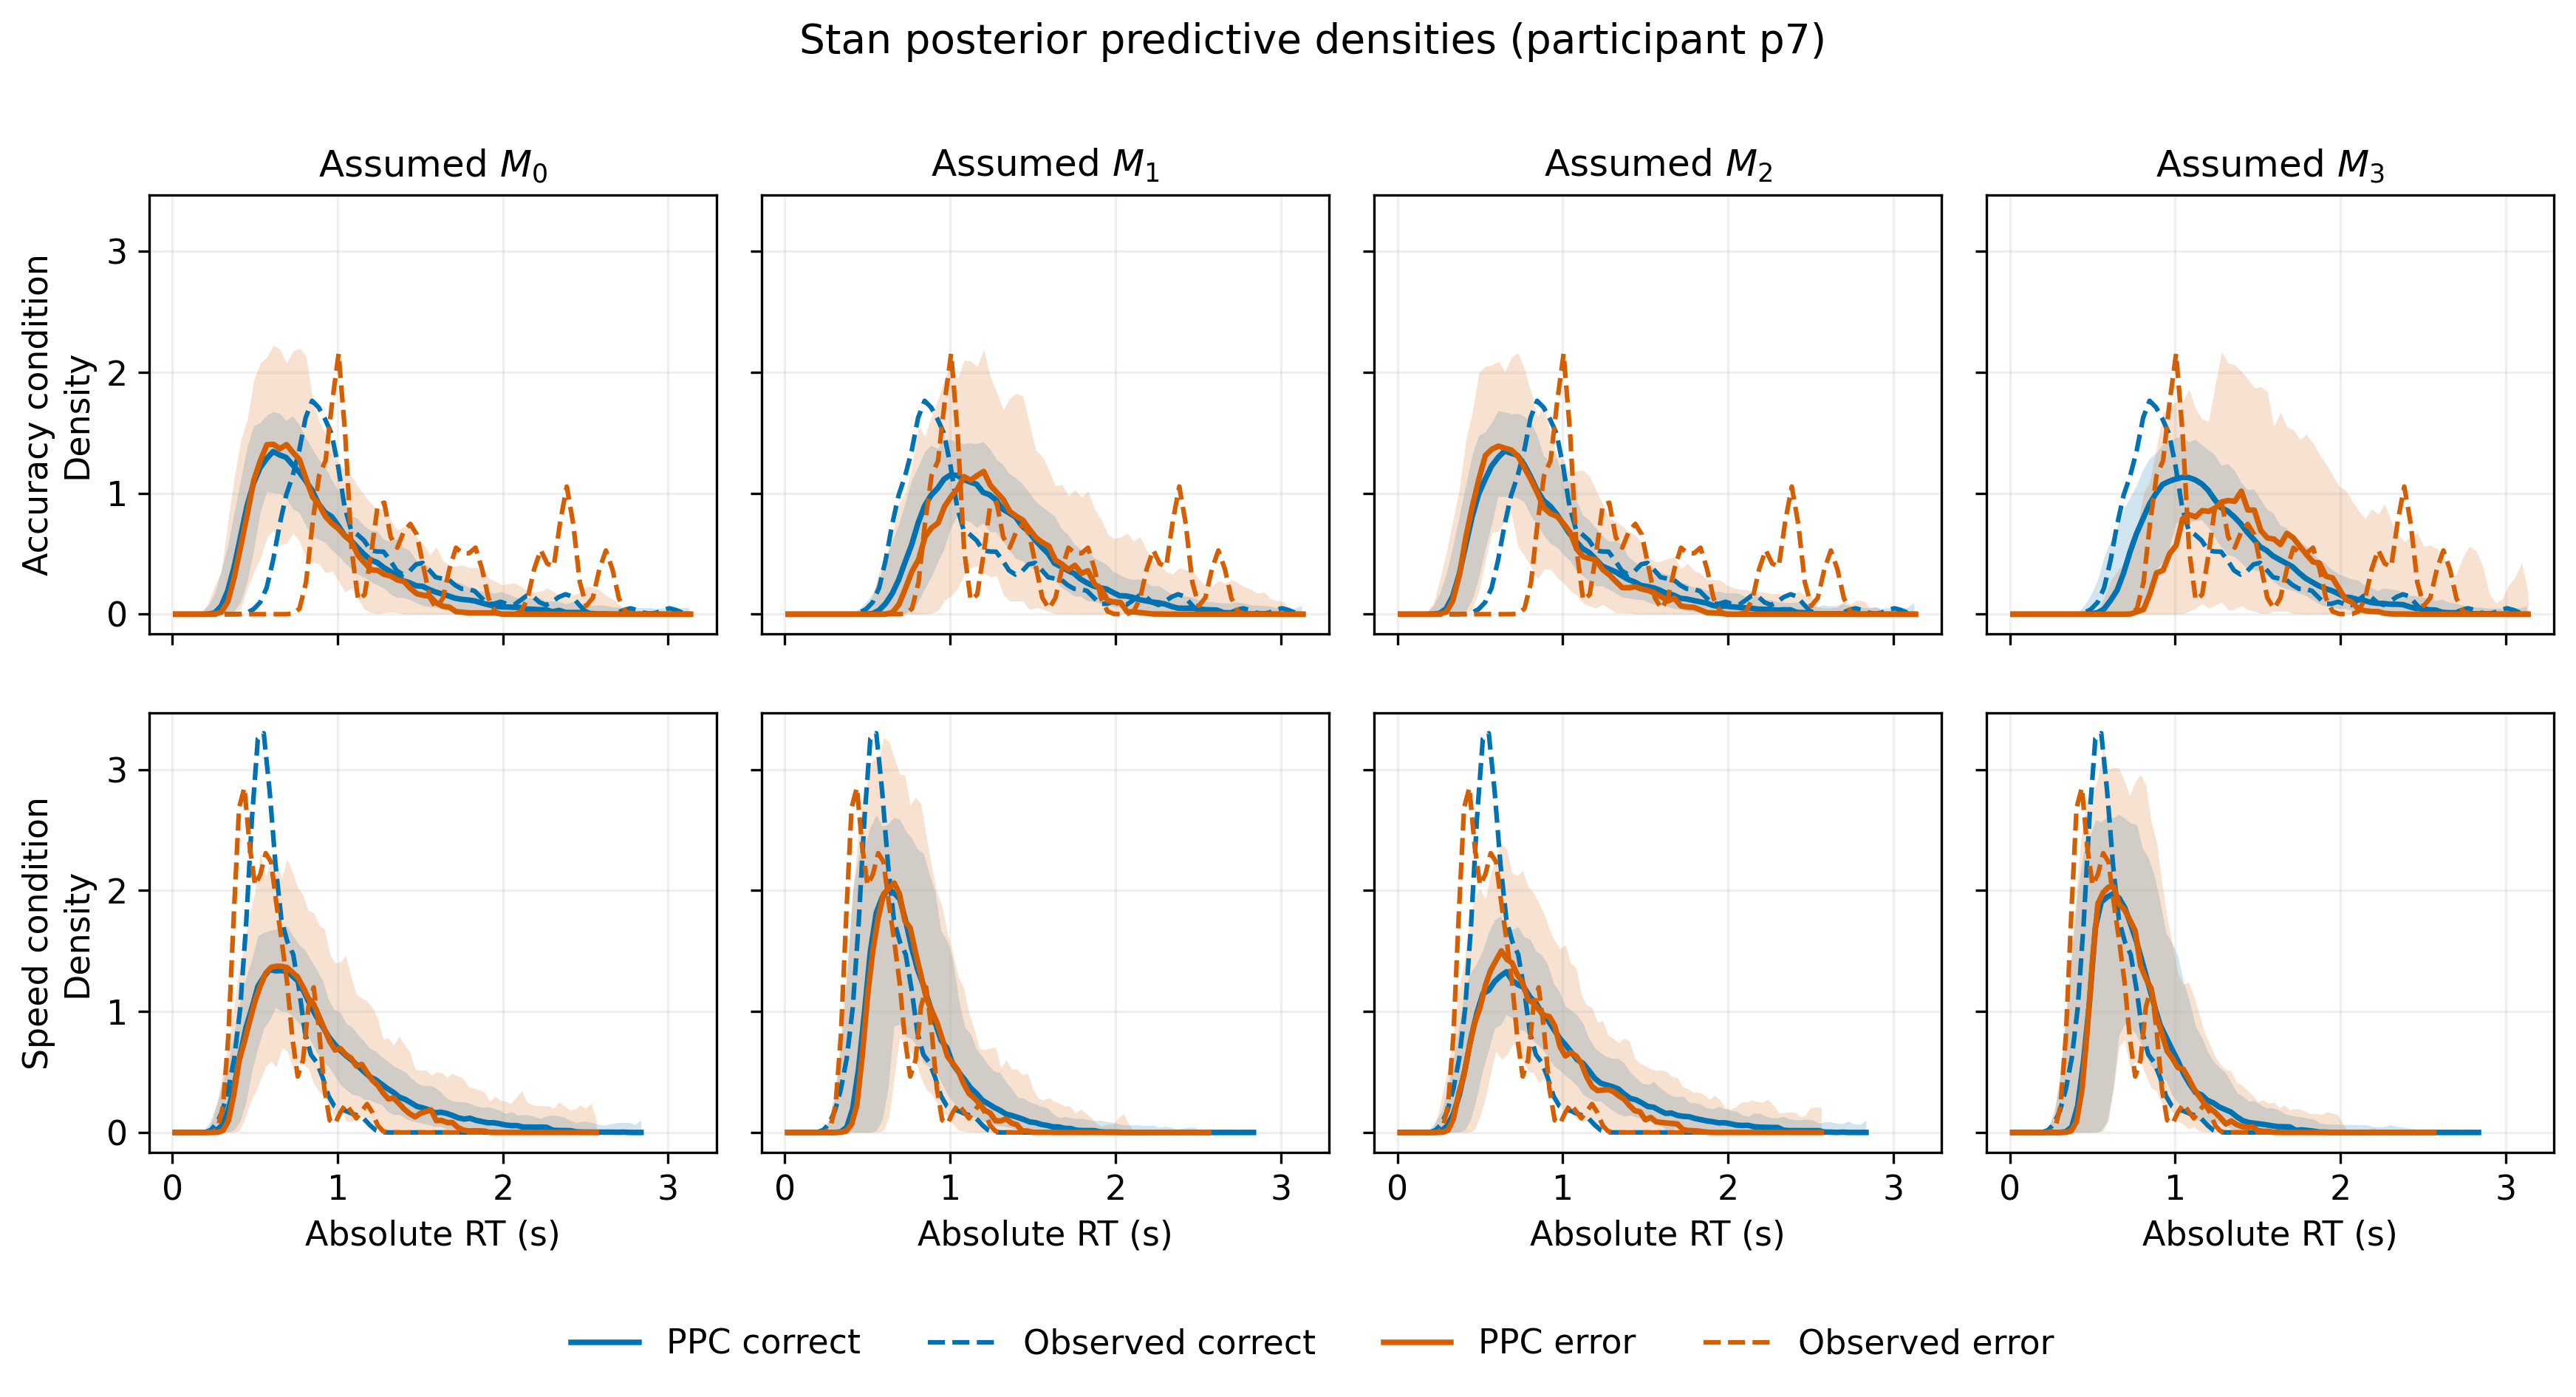

,summary,participant,density_cache,figure
0,S1D,p7,/Users/yimingzang/Documents/Project/benchmark2...,/Users/yimingzang/Documents/Project/benchmark2...
1,S2D,p7,/Users/yimingzang/Documents/Project/benchmark2...,/Users/yimingzang/Documents/Project/benchmark2...
2,S4D,p7,/Users/yimingzang/Documents/Project/benchmark2...,/Users/yimingzang/Documents/Project/benchmark2...
3,S6D,p7,/Users/yimingzang/Documents/Project/benchmark2...,/Users/yimingzang/Documents/Project/benchmark2...


,source,participant,density_cache,figure
0,Stan,p7,/Users/yimingzang/Documents/Project/benchmark2...,/Users/yimingzang/Documents/Project/benchmark2...


In [9]:
from IPython.display import Image, display

DENSITY_RECOMPUTE = True
DENSITY_PARTICIPANT_SEED = 2025
DENSITY_PARTICIPANT = random_ppc_participant(
    dataset="empirical",
    seed=DENSITY_PARTICIPANT_SEED,
)
print(
    f"Randomly selected participant: {DENSITY_PARTICIPANT} "
    f"(seed={DENSITY_PARTICIPANT_SEED})"
)

npe_density_outputs = generate_npe_ppc_density_figures(
    summary_multipliers=(1, 2, 4, 6),
    dataset="empirical",
    participant_id=DENSITY_PARTICIPANT,
    num_draws=128,
    interval=0.90,
    num_bins=80,
    batch_size=8,
    seed=2025,
    recompute=DENSITY_RECOMPUTE,
)

stan_density_output = generate_stan_ppc_density_figure(
    dataset="empirical",
    participant_id=DENSITY_PARTICIPANT,
    num_draws=128,
    interval=0.90,
    num_bins=80,
    seed=2025,
    recompute=DENSITY_RECOMPUTE,
)

for path in npe_density_outputs["figure"]:
    display(Image(filename=path))
for path in stan_density_output["figure"]:
    display(Image(filename=path))

display(npe_density_outputs)
display(stan_density_output)